<a href="https://colab.research.google.com/github/mridulasrinivasula-svg/OPTN-Model/blob/main/OPTN_Dt_beta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PARAMETER ESTIMATION RESULTS
Number of runs: 10000
Beta range: 0.0001 to 0.02
Best beta: 0.00632070
Best MSE: 492999.95
Best RMSE: 702.14
R-squared: 0.3234

Year | Actual D | Predicted D | Error
---------------------------------------------
1996 |      3804 |     3865.90 |   -61.90
1997 |      4067 |     4087.96 |   -20.96
1998 |      4570 |     4304.29 |   265.71
1999 |      5048 |     5044.11 |     3.89
2000 |      5957 |     5494.09 |   462.91
2001 |      6622 |     6828.35 |  -206.35
2002 |      6631 |     7245.14 |  -614.14
2003 |      6828 |     6598.09 |   229.91
2004 |      7005 |     6981.84 |    23.16
2005 |      6904 |     7137.72 |  -233.72
2006 |      6733 |     6759.36 |   -26.36
2007 |      6315 |     6519.44 |  -204.44
2008 |      6218 |     5857.08 |   360.92
2009 |      6610 |     6081.70 |   528.30
2010 |      6561 |     6960.22 |  -399.22
2011 |      6023 |     6470.53 |  -447.53
2012 |      5867 |     5446.93 |   420.07
2013 |      5989 |     5673.92 |   315.08
201

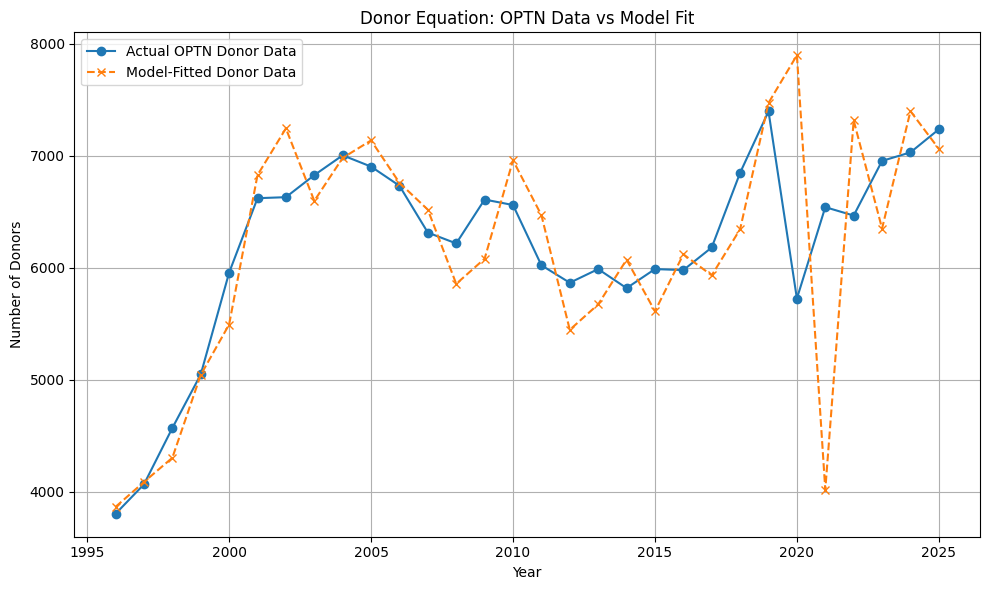

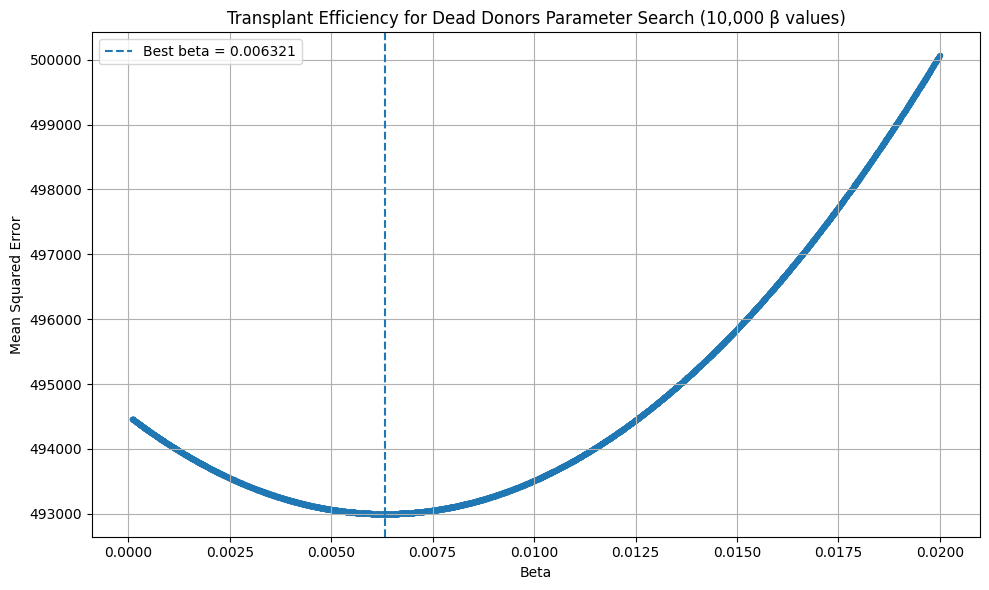

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

years = np.arange(1995, 2026)

D = np.array([
    3496, 3804, 4067, 4570, 5048, 5957, 6622, 6631,
    6828, 7005, 6904, 6733, 6315, 6218, 6610, 6561,
    6023, 5867, 5989, 5819, 5989, 5980, 6182, 6849,
    7397, 5726, 6542, 6467, 6955, 7031, 7237
], dtype=float)

B = np.array([
     392,  308,  263,  503,  478,  909,  665,    9,
     197,  177, -101, -171, -418,  -97,  392,  -49,
    -538, -156,  122, -170,  170,   -9,  202,  667,
     548, -1671, 816,  -75,  488,   76,  206
], dtype=float)

#  DONOR MODEL
# D(t+1) = D(t) + B(t) - beta*D(t)

D_current = D[:-1]
B_current = B[:-1]
D_actual_next = D[1:]

def donor_prediction(beta):
    return D_current + B_current - beta * D_current


def mean_squared_error(beta):
    predicted = donor_prediction(beta)
    return np.mean((D_actual_next - predicted) ** 2)


#10000 beta values

np.random.seed(42)

n_runs = 10000

beta_values = np.random.uniform(
    0.0001,
    0.02,
    n_runs
)

errors = np.array([
    mean_squared_error(beta)
    for beta in beta_values
])


# 6. FIND BEST BETA

best_index = np.argmin(errors)

best_beta = beta_values[best_index]
best_mse = errors[best_index]
best_rmse = np.sqrt(best_mse)

print("=" * 50)
print("PARAMETER ESTIMATION RESULTS")
print("=" * 50)

print(f"Number of runs: {n_runs}")
print(f"Beta range: 0.0001 to 0.02")
print(f"Best beta: {best_beta:.8f}")
print(f"Best MSE: {best_mse:.2f}")
print(f"Best RMSE: {best_rmse:.2f}")


#
# 7. GENERATE FITTED VALUES
#

D_fitted = donor_prediction(best_beta)

#
# 8. CALCULATE R-SQUARED
#

SS_res = np.sum((D_actual_next - D_fitted) ** 2)
SS_tot = np.sum((D_actual_next - np.mean(D_actual_next)) ** 2)

R_squared = 1 - (SS_res / SS_tot)

print(f"R-squared: {R_squared:.4f}")



print("\nYear | Actual D | Predicted D | Error")
print("-" * 45)

for i in range(len(D_actual_next)):
    year = years[i + 1]
    actual = D_actual_next[i]
    predicted = D_fitted[i]
    error = actual - predicted

    print(
        f"{year} | "
        f"{actual:9.0f} | "
        f"{predicted:11.2f} | "
        f"{error:8.2f}"
    )

plt.figure(figsize=(10, 6))

plt.plot(
    years[1:],
    D_actual_next,
    marker="o",
    label="Actual OPTN Donor Data"
)

plt.plot(
    years[1:],
    D_fitted,
    marker="x",
    linestyle="--",
    label="Model-Fitted Donor Data"
)

plt.xlabel("Year")
plt.ylabel("Number of Donors")
plt.title("Donor Equation: OPTN Data vs Model Fit")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))

plt.scatter(
    beta_values,
    errors,
    s=8
)

plt.axvline(
    best_beta,
    linestyle="--",
    label=f"Best beta = {best_beta:.6f}"
)

plt.xlabel("Beta")
plt.ylabel("Mean Squared Error")
plt.title("Transplant Efficiency for Dead Donors Parameter Search (10,000 β values)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()